In [1]:
!pip install -q google-genai pymupdf pydantic

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 25.8/25.8 MB 65.3 MB/s eta 0:00:00


In [4]:
import google.genai
import fitz
import pydantic

print("Everything is installed correctly!")

Everything is installed correctly!


In [5]:
import fitz
import fastapi
import pydantic

print("PyMuPDF:", fitz.__doc__.split()[1])
print("FastAPI:", fastapi.__version__)
print("Pydantic:", pydantic.__version__)

print("Environment ready ✅")

PyMuPDF: 1.28.2:
FastAPI: 0.141.1
Pydantic: 2.13.4
Environment ready ✅


In [6]:
from google.colab import files

uploaded = files.upload()

Saving test_photosynthesis.pdf to test_photosynthesis (1).pdf


In [7]:
import fitz
import os

pdf_name = list(uploaded.keys())[0]

doc = fitz.open(pdf_name)

print("File:", pdf_name)
print("Pages:", len(doc))

for i, page in enumerate(doc):
    text = page.get_text()

    print(f"\n--- PAGE {i + 1} ---")
    print(text[:2000])

File: test_photosynthesis (1).pdf
Pages: 5

--- PAGE 1 ---
Photosynthesis: Nature's Solar
Panels
A Middle School Science Guide
Introduction
Have you ever wondered how plants get their food? Unlike animals, plants don't go to the
grocery store or hunt for their meals. Instead, they make their own food using sunlight, water,
and carbon dioxide from the air. This amazing process is called photosynthesis, and it's one
of the most important chemical reactions on Earth. Without photosynthesis, most life as we
know it would not exist.
In this lesson, we will explore how photosynthesis works, why it matters, and how scientists
are trying to copy this natural process to create clean energy for the future.
The Photosynthesis Equation
At its core, photosynthesis is a chemical reaction that converts light energy into chemical
energy. Scientists often write it as a simple equation:
6COI
+ 6HIO
+ Light Energy
→ CIHIIOI
+ 6OI
Carbon Dioxide
Water
Sunlight
Glucose (Sugar)
Oxygen
In words, this means: 

In [8]:
import fitz
import os

image_dir = "extracted_images"
os.makedirs(image_dir, exist_ok=True)

image_count = 0

for page_number, page in enumerate(doc):
    images = page.get_images(full=True)

    for image_index, image in enumerate(images):
        xref = image[0]

        base_image = doc.extract_image(xref)

        image_bytes = base_image["image"]
        image_ext = base_image["ext"]

        filename = f"page_{page_number + 1}_image_{image_index + 1}.{image_ext}"
        filepath = os.path.join(image_dir, filename)

        with open(filepath, "wb") as f:
            f.write(image_bytes)

        image_count += 1

        print("Extracted:", filepath)

print(f"\nTotal images: {image_count}")


Total images: 0


In [9]:
import os

print(os.listdir("extracted_images"))

[]


In [10]:
from IPython.display import display, Image
import os

for filename in os.listdir("extracted_images"):
    filepath = os.path.join("extracted_images", filename)

    print(filename)
    display(Image(filename=filepath))

In [11]:
for page_number, page in enumerate(doc):
    drawings = page.get_drawings()

    print(f"Page {page_number + 1}: {len(drawings)} vector drawings")

Page 1: 0 vector drawings
Page 2: 18 vector drawings
Page 3: 7 vector drawings
Page 4: 16 vector drawings
Page 5: 0 vector drawings


In [12]:
from PIL import Image
import os

render_dir = "rendered_pages"
os.makedirs(render_dir, exist_ok=True)

for page_number, page in enumerate(doc):
    # Render page at higher resolution
    pix = page.get_pixmap(matrix=fitz.Matrix(2, 2), alpha=False)

    filepath = os.path.join(
        render_dir,
        f"page_{page_number + 1}.png"
    )

    pix.save(filepath)

    print("Rendered:", filepath)

Rendered: rendered_pages/page_1.png
Rendered: rendered_pages/page_2.png
Rendered: rendered_pages/page_3.png
Rendered: rendered_pages/page_4.png
Rendered: rendered_pages/page_5.png



 page_1.png


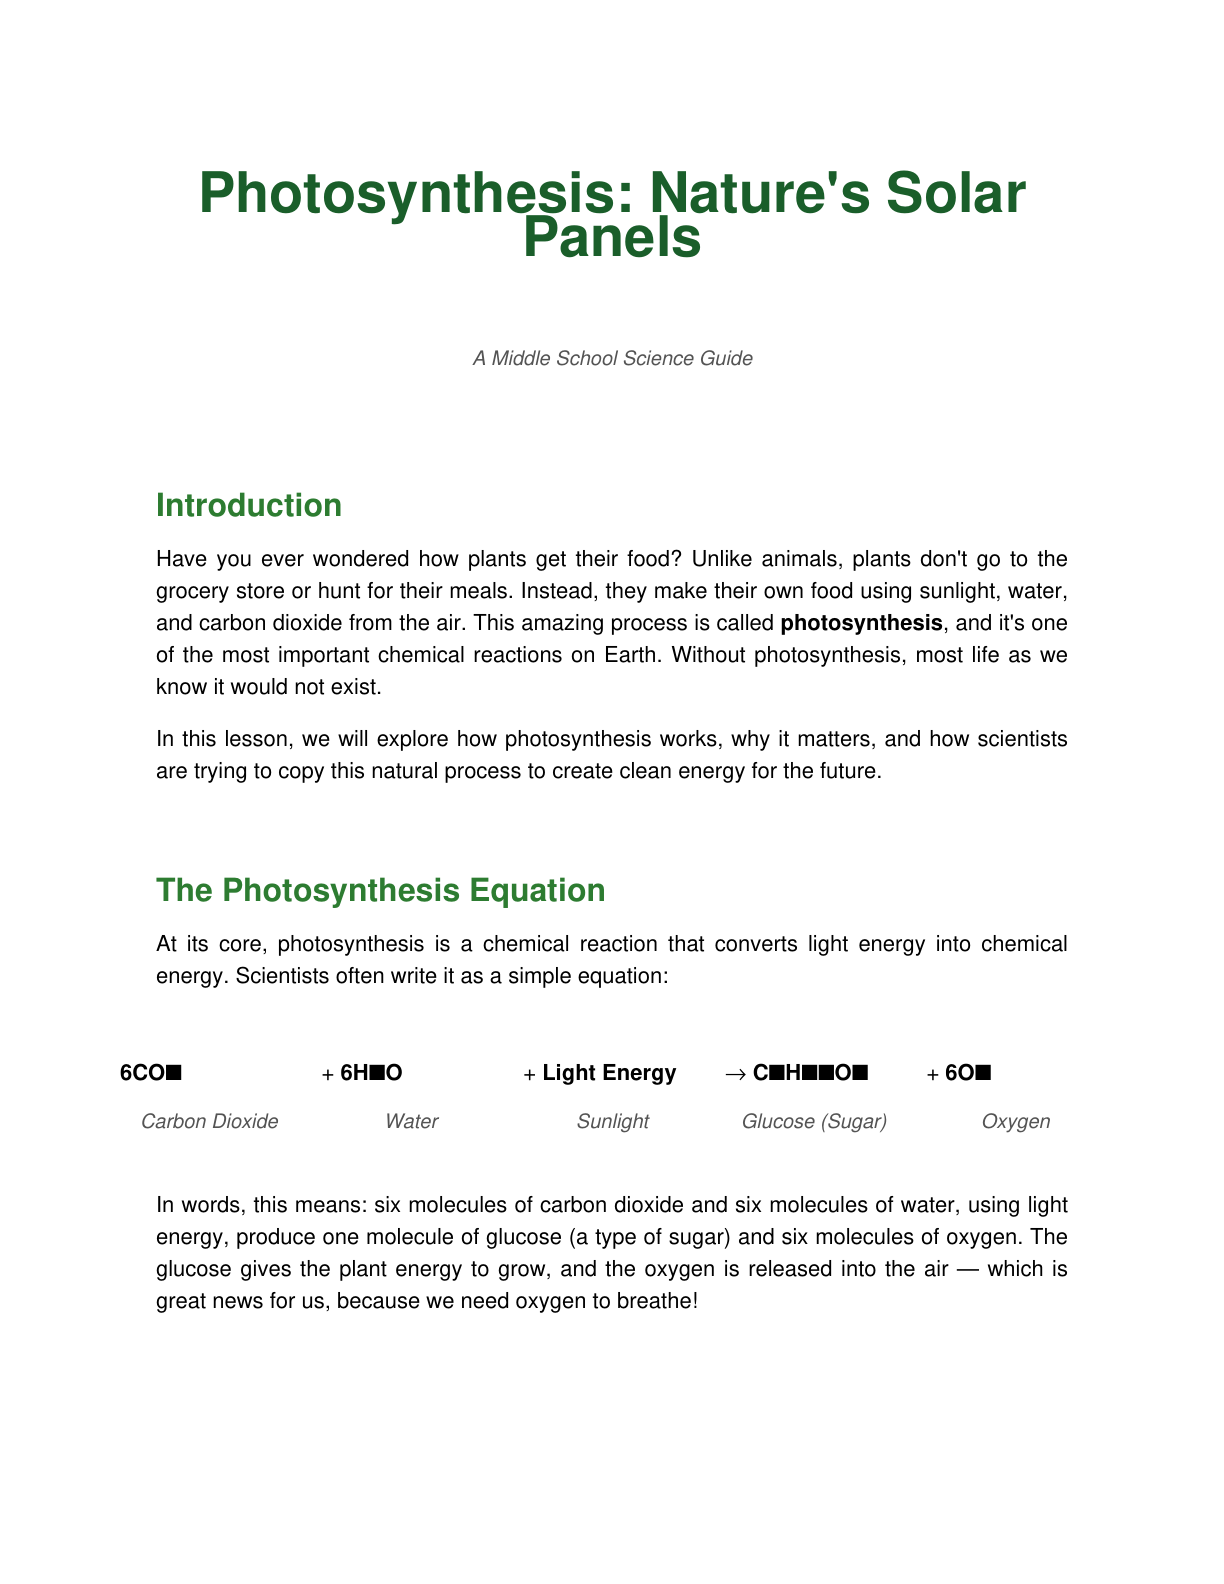


 page_2.png


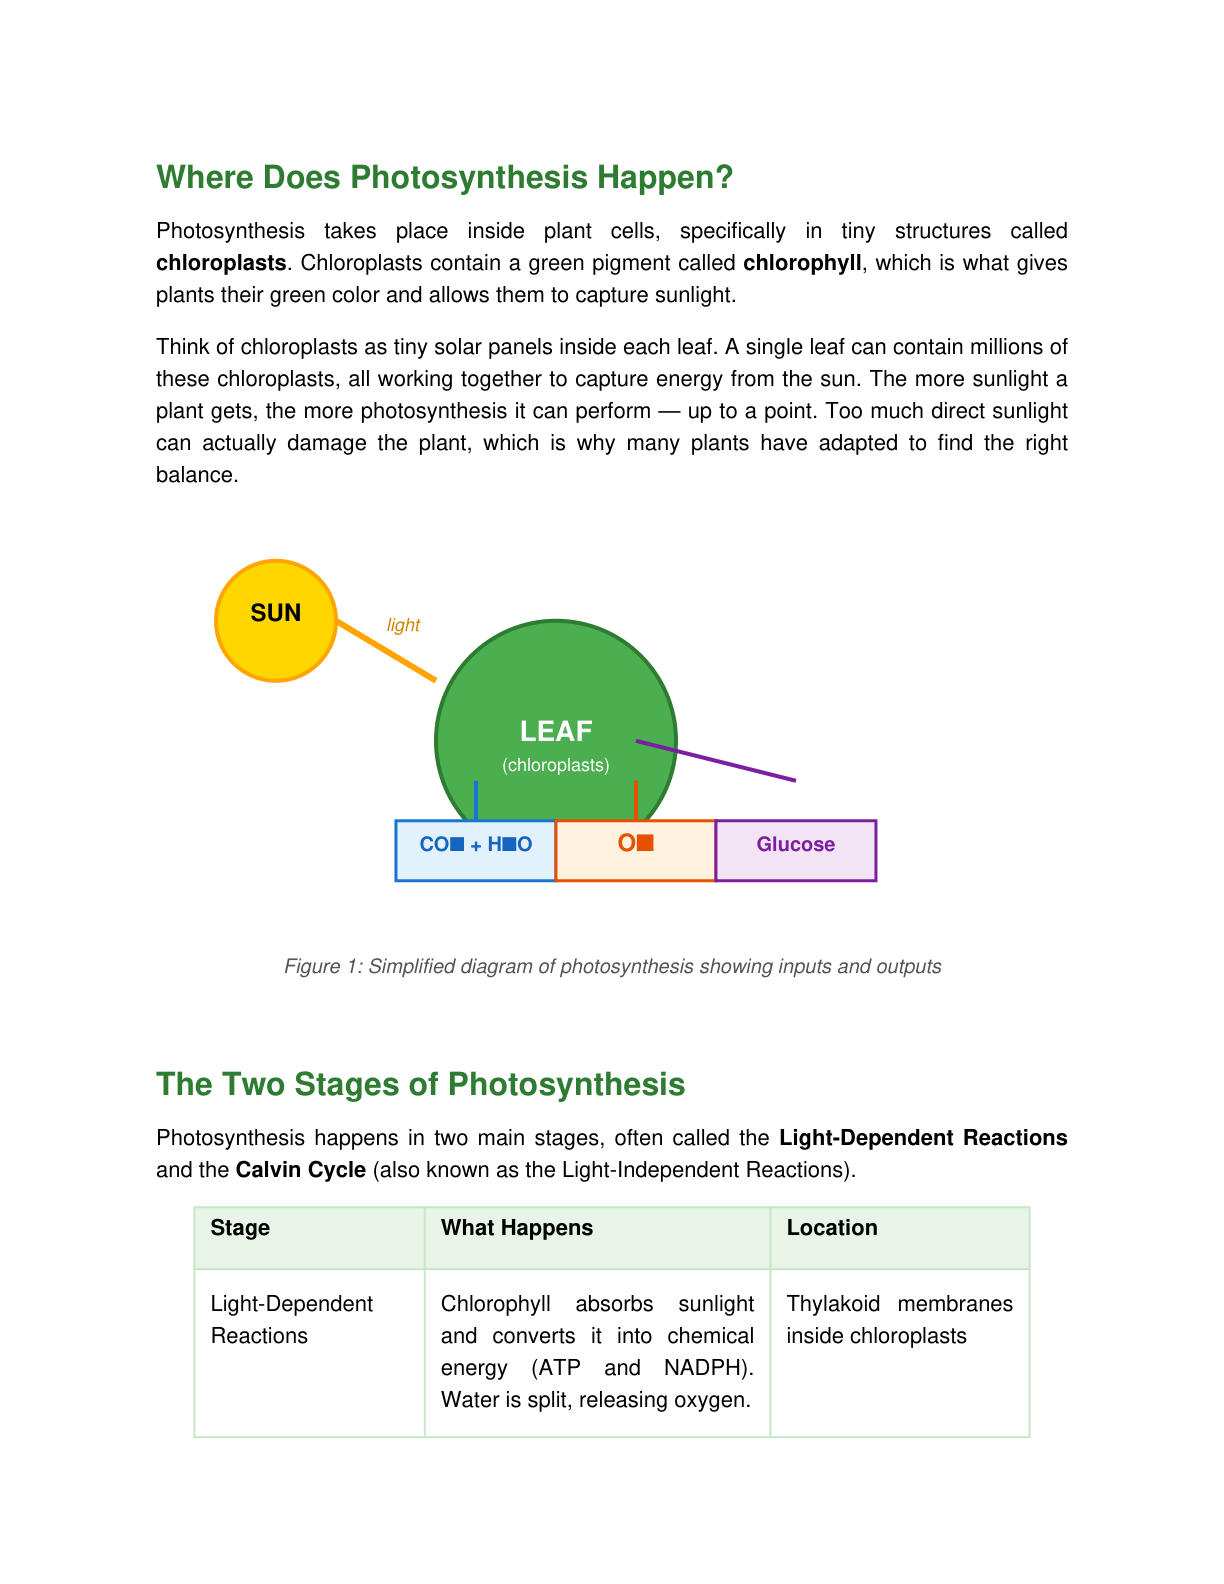


 page_3.png


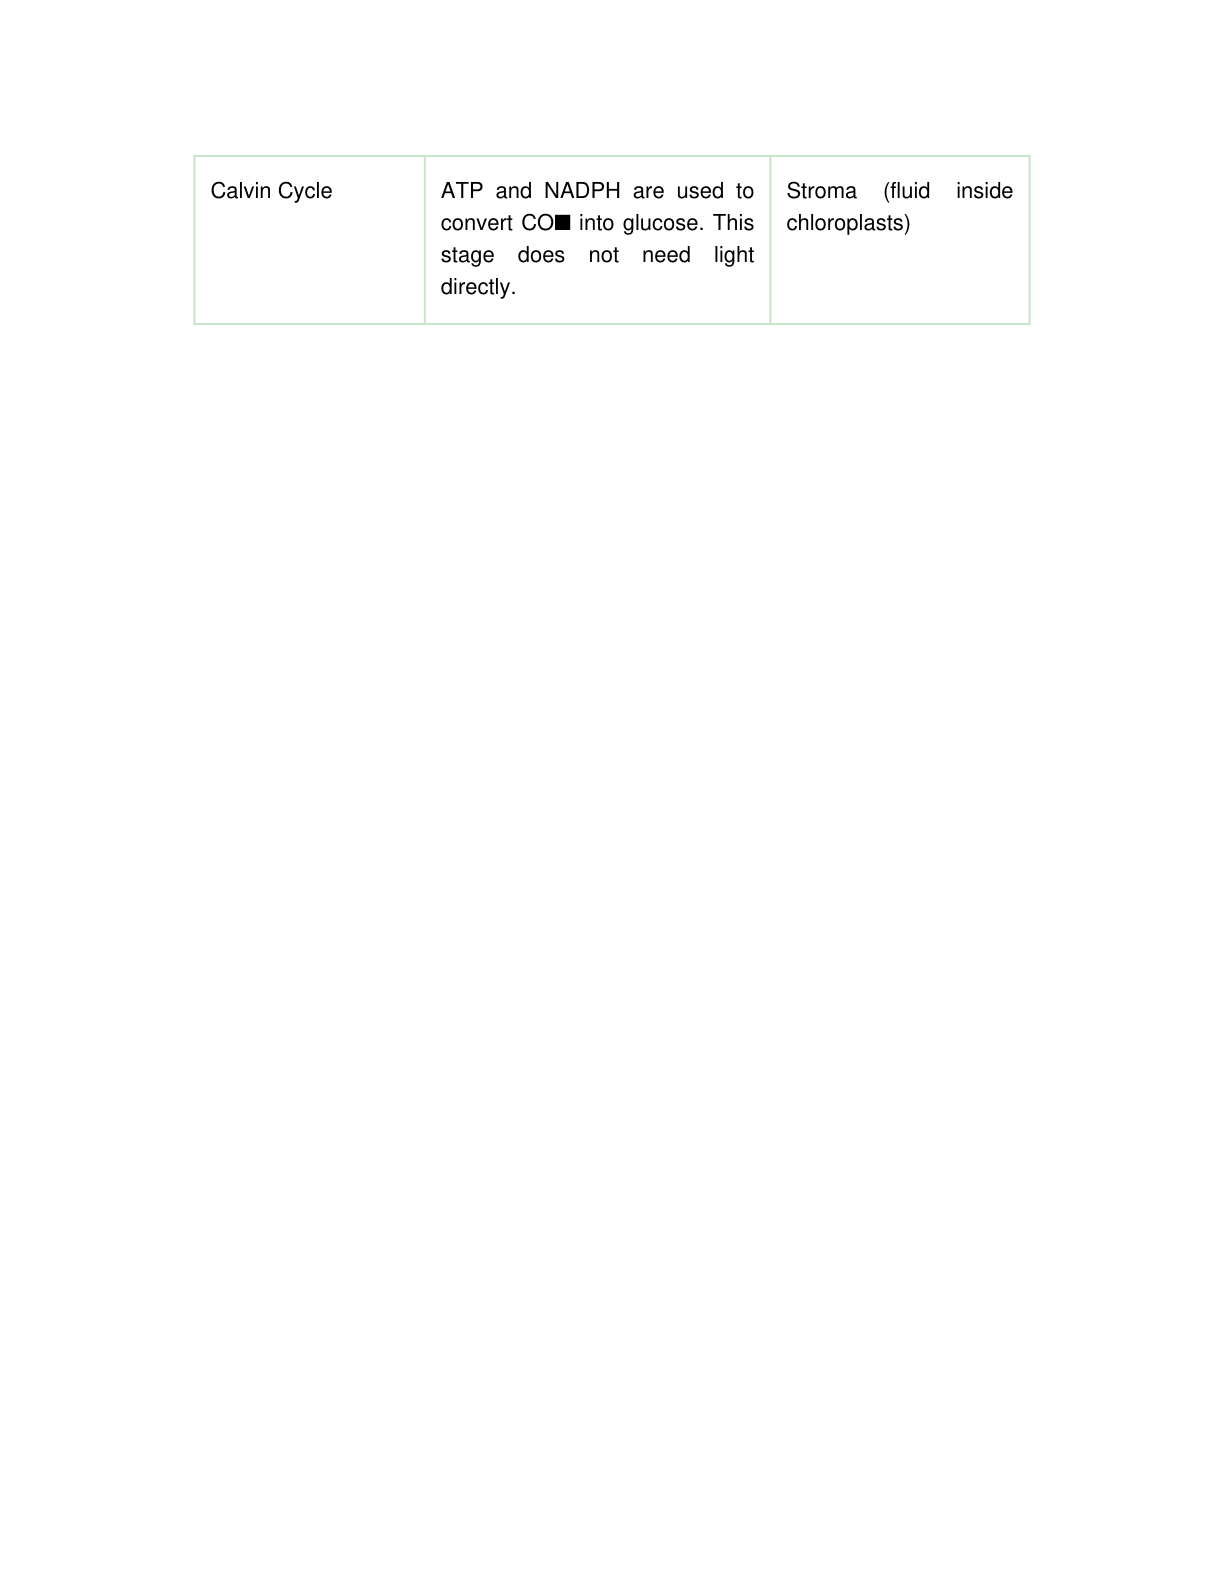


 page_4.png


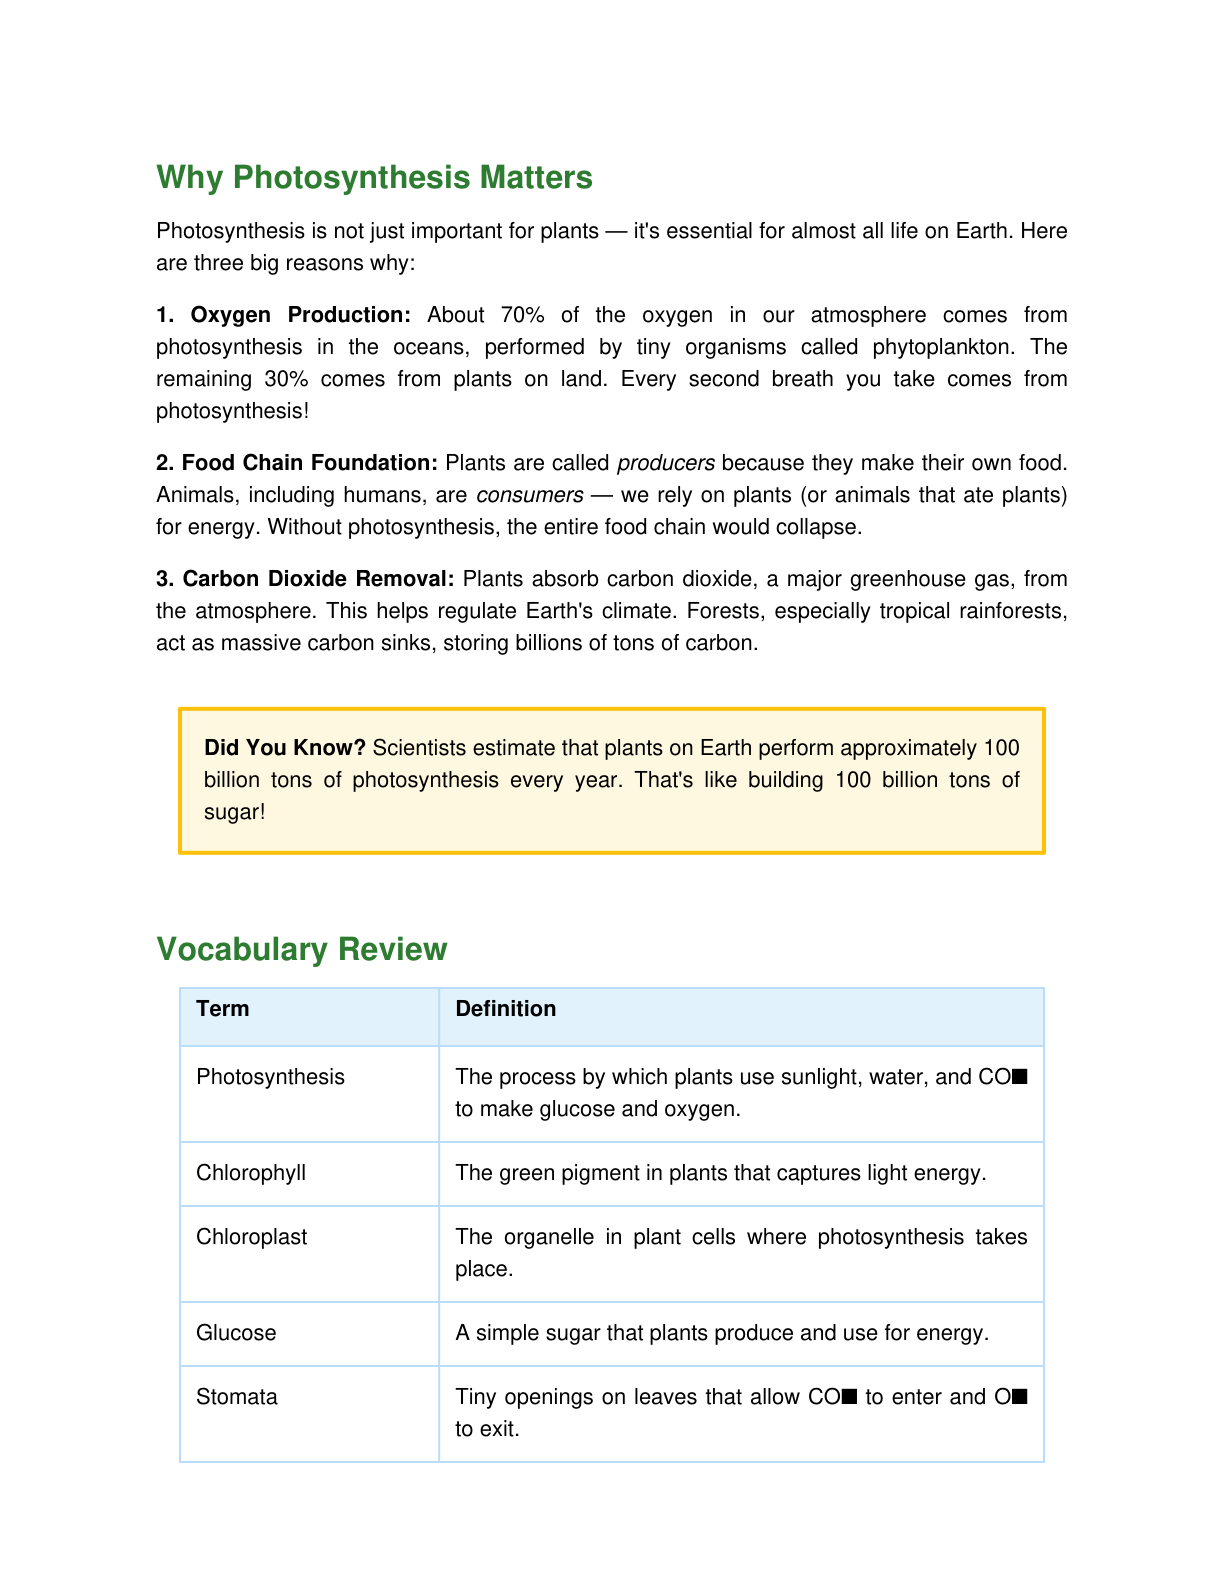


 page_5.png


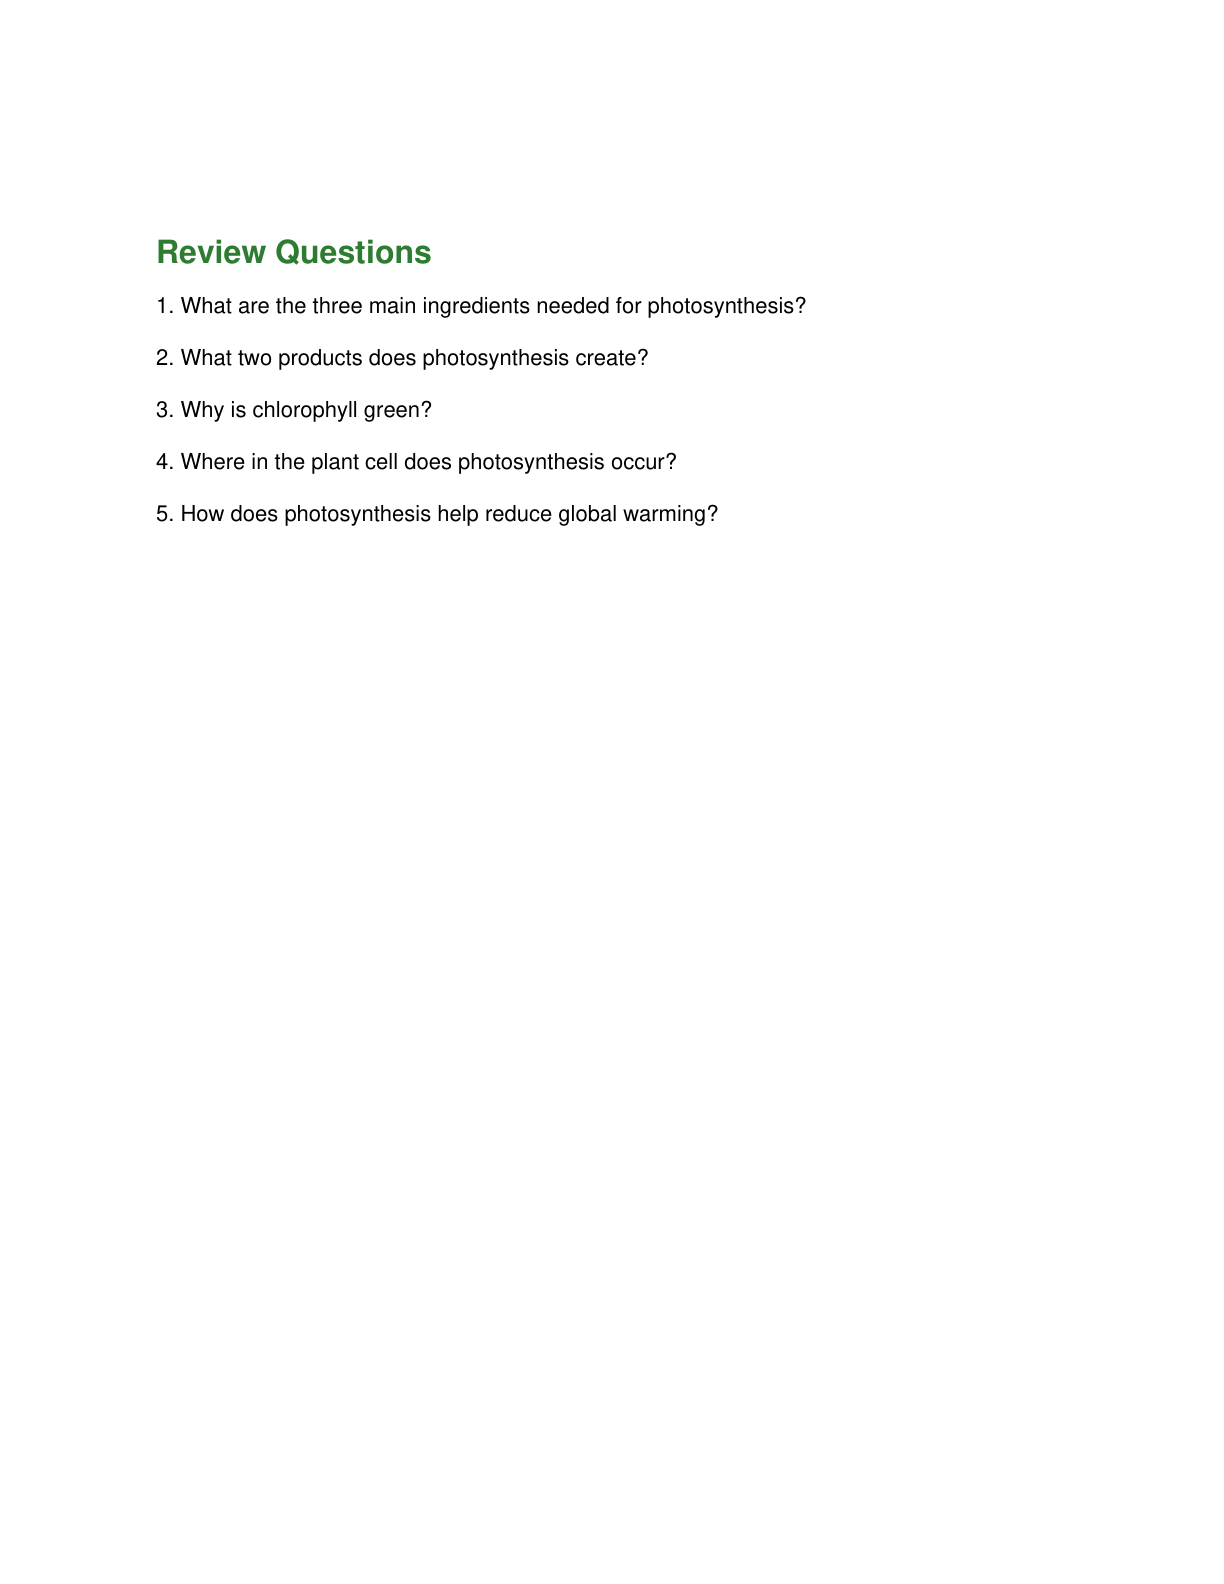

In [13]:
from IPython.display import display
import os

for filename in sorted(os.listdir("rendered_pages")):
    filepath = os.path.join("rendered_pages", filename)

    print("\n", filename)
    display(Image.open(filepath))

In [14]:
import os
from getpass import getpass

os.environ["ANTHROPIC_API_KEY"] = getpass("Enter your Claude API key: ")

Enter your Claude API key: ··········


In [13]:
!pip install -q anthropic

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 48.2 MB/s eta 0:00:00


In [15]:
import anthropic

client = anthropic.Anthropic(
    api_key=os.environ["ANTHROPIC_API_KEY"]
)

print("Claude client initialized ✅")

Claude client initialized ✅


In [16]:
import os

image_path = "rendered_pages/page_2.png"

print("Exists:", os.path.exists(image_path))
print("Path:", image_path)

Exists: True
Path: rendered_pages/page_2.png


In [17]:
import base64
import mimetypes

image_path = "rendered_pages/page_2.png"

with open(image_path, "rb") as f:
    image_data = base64.b64encode(f.read()).decode("utf-8")

media_type = mimetypes.guess_type(image_path)[0] or "image/png"

response = client.messages.create(
    model="claude-sonnet-4-6",
    max_tokens=1000,
    system="""You are an accessibility expert specializing in educational content.

Your job is to analyze educational diagrams and create descriptions that allow
a blind or visually impaired learner to understand the important educational
information contained in the visual.

Do not merely describe colors, shapes, or say that an image is a diagram.

Focus on:
- what the diagram represents
- important labels
- relationships between elements
- processes
- directions or sequences
- scientifically or academically important information

Do not invent information that cannot be reasonably inferred from the image.""",
    messages=[
        {
            "role": "user",
            "content": [
                {
                    "type": "image",
                    "source": {
                        "type": "base64",
                        "media_type": media_type,
                        "data": image_data,
                    },
                },
                {
                    "type": "text",
                    "text": "Analyze this educational page and produce an accessibility description for the meaningful visual content on it."
                }
            ],
        }
    ],
)

print(response.content[0].text)

## Accessibility Description for Figure 1: Simplified Diagram of Photosynthesis

This diagram illustrates photosynthesis as a process with inputs going **into** a leaf and outputs coming **out of** it.

### Inputs (what the leaf takes in):

- **Sunlight**: An arrow points from the Sun toward the leaf, labeled "light," indicating that light energy from the sun enters the leaf.
- **Carbon dioxide (CO₂) and Water (H₂O)**: These two raw materials are shown entering the leaf from below, representing absorption from the air and roots respectively.

### Central Structure:

- The **Leaf** is the central element of the diagram, labeled with "(chloroplasts)" beneath it, identifying the specific structures within the leaf where photosynthesis occurs.

### Outputs (what the leaf produces):

Two products exit the leaf:

- **Oxygen (O₂)**: Shown leaving the leaf downward, representing the oxygen released as a byproduct when water molecules are split during photosynthesis.
- **Glucose**: Shown leavin

In [1]:
import base64
import mimetypes


def analyze_visual(image_path: str) -> str:
    """
    Analyze an educational visual using Claude Vision
    and return an accessibility-focused description.
    """

    with open(image_path, "rb") as f:
        image_data = base64.b64encode(f.read()).decode("utf-8")

    media_type = mimetypes.guess_type(image_path)[0] or "image/png"

    response = client.messages.create(
        model="claude-sonnet-4-6",
        max_tokens=1000,
        system="""You are an accessibility expert specializing in educational content.

Analyze educational diagrams and visuals for learners who may be blind
or visually impaired.

Describe:
- what the visual represents
- important labels
- relationships between elements
- processes or directions
- academically important information

Do not focus on decorative details.

Do not invent information that cannot reasonably be inferred.

Keep the description accurate, educational, and suitable for a screen reader.""",

        messages=[
            {
                "role": "user",
                "content": [
                    {
                        "type": "image",
                        "source": {
                            "type": "base64",
                            "media_type": media_type,
                            "data": image_data,
                        },
                    },
                    {
                        "type": "text",
                        "text": "Create an accessibility description for the meaningful educational visual content on this page."
                    }
                ],
            }
        ],
    )

    return response.content[0].text


In [18]:
description = analyze_visual(
    "rendered_pages/page_2.png"
)

print(description)

## Accessibility Description for Figure 1

**Figure 1: Simplified diagram of photosynthesis showing inputs and outputs**

This diagram illustrates the basic inputs and outputs of photosynthesis using simple shapes and color-coded labels.

### Elements and Their Relationships

**The Sun** is represented by a yellow circle on the left, labeled "SUN." An orange diagonal arrow points from the Sun toward the center of the diagram, labeled *"light"*, indicating that light energy travels from the Sun to the leaf.

**The Leaf** is represented by a large green circle in the center, labeled "LEAF" with the word "(chloroplasts)" beneath it, indicating that chloroplasts are located inside the leaf. This is where photosynthesis takes place.

**Three colored rectangles** are arranged in a row beneath the leaf, connected to it by vertical lines:

- **Blue rectangle** on the left, labeled **"CO₂ + H₂O"** — these are the **inputs** (raw materials) entering the leaf: carbon dioxide and water.
- **Red/or

In [19]:
from pydantic import BaseModel, Field
from typing import List


class VisualAnalysis(BaseModel):
    visual_type: str = Field(
        description="Type of educational visual, such as diagram, chart, graph, table, or illustration"
    )

    title: str = Field(
        description="Short title describing the visual"
    )

    accessibility_description: str = Field(
        description="Detailed description suitable for a blind or visually impaired learner"
    )

    key_elements: List[str] = Field(
        description="Important elements, labels, or concepts shown in the visual"
    )

    relationships: List[str] = Field(
        description="Important relationships, directions, sequences, or processes shown"
    )

    educational_significance: str = Field(
        description="What the learner should understand from this visual"
    )

In [20]:
from pydantic import BaseModel, Field
from typing import List


class VisualAnalysis(BaseModel):
    visual_type: str = Field(
        description="Type of educational visual, such as diagram, chart, graph, table, or illustration"
    )

    title: str = Field(
        description="Short title describing the visual"
    )

    accessibility_description: str = Field(
        description="Detailed description suitable for a blind or visually impaired learner"
    )

    key_elements: List[str] = Field(
        description="Important elements, labels, or concepts shown in the visual"
    )

    relationships: List[str] = Field(
        description="Important relationships, directions, sequences, or processes shown"
    )

    educational_significance: str = Field(
        description="What the learner should understand from this visual"
    )

print("VisualAnalysis model ready ✅")

VisualAnalysis model ready ✅


In [24]:
import base64
import mimetypes
import json


def analyze_visual_structured(image_path: str) -> VisualAnalysis:

    with open(image_path, "rb") as f:
        image_data = base64.b64encode(f.read()).decode("utf-8")

    media_type = mimetypes.guess_type(image_path)[0] or "image/png"

    response = client.messages.create(
        model="claude-sonnet-4-6",
        max_tokens=1500,

        system="""You are an accessibility expert specializing in educational content.

Analyze the educational visual provided.

Your goal is to create an accurate representation that can be used
by a blind or visually impaired learner.

Focus on educational meaning rather than decorative details.

Identify:
- visual type
- important labels
- important elements
- relationships
- processes
- directions
- educational significance

Do not invent information.

Return ONLY valid JSON matching this exact structure:

{
  "visual_type": "...",
  "title": "...",
  "accessibility_description": "...",
  "key_elements": ["..."],
  "relationships": ["..."],
  "educational_significance": "..."
}
""",

        messages=[
            {
                "role": "user",
                "content": [
                    {
                        "type": "image",
                        "source": {
                            "type": "base64",
                            "media_type": media_type,
                            "data": image_data,
                        },
                    },
                    {
                        "type": "text",
                        "text": "Analyze this educational visual and return the required JSON."
                    }
                ],
            }
        ],
    )

    raw_text = response.content[0].text


    raw_text = raw_text.strip()

    if raw_text.startswith("```"):
        raw_text = raw_text.replace("```json", "")
        raw_text = raw_text.replace("```", "")
        raw_text = raw_text.strip()

    data = json.loads(raw_text)

    return VisualAnalysis.model_validate(data)
    result = analyze_visual_structured(
    "rendered_pages/page_2.png"
)

print("SUCCESS!")
print(result.model_dump_json(indent=2))

SUCCESS!
{
  "visual_type": "Simplified diagram with labeled components and directional arrows showing inputs and outputs of photosynthesis",
  "title": "Where Does Photosynthesis Happen? - Figure 1: Simplified diagram of photosynthesis showing inputs and outputs",
  "accessibility_description": "A diagram showing the process of photosynthesis centered on a green circle labeled LEAF with the subtext 'chloroplasts'. On the left, a yellow circle labeled SUN has an orange arrow pointing toward the leaf labeled 'light', representing sunlight input. Below the leaf are three colored rectangular boxes representing outputs and inputs: a blue box on the left showing CO2 + H2O (carbon dioxide and water as inputs), a red box in the center showing O2 (oxygen as output), and a purple box on the right showing Glucose (as output). A blue vertical line connects the leaf to the CO2 + H2O box, a red vertical line connects the leaf to the O2 box, and a purple diagonal line connects the leaf to the Glucos

In [23]:
# Tests the structured visual analysis

result = analyze_visual_structured(
    "rendered_pages/page_2.png"
)

print("SUCCESS! Claude analyzed the image.")
print()
print(result.model_dump_json(indent=2))

SUCCESS! Claude analyzed the image.

{
  "visual_type": "Simplified diagram with labeled components and directional arrows showing inputs and outputs of photosynthesis",
  "title": "Where Does Photosynthesis Happen? - Figure 1: Simplified diagram of photosynthesis showing inputs and outputs",
  "accessibility_description": "A diagram showing the process of photosynthesis centered on a green circle labeled LEAF with the subtext 'chloroplasts'. On the left, a yellow circle labeled SUN has an orange arrow pointing toward the leaf labeled 'light', representing sunlight input. Below the leaf are three colored rectangular boxes representing outputs and inputs: a blue box on the left showing CO2 + H2O (carbon dioxide and water as inputs), a red box in the center showing O2 (oxygen as output), and a purple box on the right showing Glucose (as output). A blue vertical line connects the leaf to the CO2 + H2O box, a red vertical line connects the leaf to the O2 box, and a purple diagonal line con

In [25]:
from pydantic import BaseModel, Field
from typing import List, Optional


class LessonSection(BaseModel):
    heading: str
    original_content: str
    easy_reading_content: str = ""
    key_points: List[str] = []


class Lesson(BaseModel):
    title: str
    subject: Optional[str] = None
    summary: str
    learning_objectives: List[str] = []
    sections: List[LessonSection] = []
    visuals: List[VisualAnalysis] = []


print("Universal Lesson model ready ✅")

Universal Lesson model ready ✅


In [26]:
lesson = Lesson(
    title="Photosynthesis",
    subject="Biology",
    summary="An introduction to photosynthesis.",
    learning_objectives=[
        "Understand the inputs and outputs of photosynthesis."
    ],
    sections=[
        LessonSection(
            heading="What is Photosynthesis?",
            original_content="Photosynthesis is the process by which plants use light energy to produce food.",
            easy_reading_content="Photosynthesis is how plants use light to make food.",
            key_points=[
                "Plants need light.",
                "Carbon dioxide and water are inputs.",
                "Oxygen and glucose are outputs."
            ]
        )
    ],
    visuals=[result]
)

print(lesson.model_dump_json(indent=2))

{
  "title": "Photosynthesis",
  "subject": "Biology",
  "summary": "An introduction to photosynthesis.",
  "learning_objectives": [
    "Understand the inputs and outputs of photosynthesis."
  ],
  "sections": [
    {
      "heading": "What is Photosynthesis?",
      "original_content": "Photosynthesis is the process by which plants use light energy to produce food.",
      "easy_reading_content": "Photosynthesis is how plants use light to make food.",
      "key_points": [
        "Plants need light.",
        "Carbon dioxide and water are inputs.",
        "Oxygen and glucose are outputs."
      ]
    }
  ],
  "visuals": [
    {
      "visual_type": "Simplified diagram with labeled components and directional arrows showing inputs and outputs of photosynthesis",
      "title": "Where Does Photosynthesis Happen? - Figure 1: Simplified diagram of photosynthesis showing inputs and outputs",
      "accessibility_description": "A diagram showing the process of photosynthesis centered on a

In [27]:
def generate_easy_reading(text: str) -> str:

    response = client.messages.create(
        model="claude-sonnet-4-6",
        max_tokens=1000,

        system="""You are an accessibility specialist for education.

Rewrite educational content so it is easier for learners with dyslexia
and learners who benefit from simplified reading.

Rules:
- Keep the original meaning accurate.
- Use short, clear sentences.
- Use simple vocabulary where possible.
- Keep important scientific or academic terms.
- Explain difficult terms briefly when needed.
- Use clear headings and bullet points.
- Do not remove important information.
- Do not add facts that were not in the original text.
""",

        messages=[
            {
                "role": "user",
                "content": f"""Rewrite the following educational content
in an easy-reading format:

{text}"""
            }
        ]
    )

    return response.content[0].text

In [28]:
easy_text = generate_easy_reading(
    """Photosynthesis is the process by which green plants
    convert light energy into chemical energy. Chlorophyll
    absorbs sunlight. Plants use carbon dioxide and water
    to produce glucose and oxygen."""
)

print(easy_text)

# Photosynthesis

## What is Photosynthesis?

Photosynthesis is how green plants make their own food using light.

---

## How Does it Work?

- Plants have a green substance called **chlorophyll**
- Chlorophyll soaks up energy from sunlight
- Plants take in **carbon dioxide** (a gas from the air)
- Plants take in **water** (from the soil)
- The plant uses the light energy to turn these into new substances

---

## What Does the Plant Make?

The plant produces two things:

- **Glucose** — a type of sugar the plant uses for energy and growth
- **Oxygen** — a gas that is released into the air

---

## Simple Summary

> Plants use **sunlight, water, and carbon dioxide** to make **glucose and oxygen**.


In [29]:
# Extracts all text from the PDF

pages_text = []

for page_number, page in enumerate(doc):
    text = page.get_text().strip()

    if text:
        pages_text.append({
            "page": page_number + 1,
            "text": text
        })

print(f"Extracted text from {len(pages_text)} pages")

for item in pages_text:
    print(f"\n--- PAGE {item['page']} ---")
    print(item["text"][:500])

Extracted text from 5 pages

--- PAGE 1 ---
Photosynthesis: Nature's Solar
Panels
A Middle School Science Guide
Introduction
Have you ever wondered how plants get their food? Unlike animals, plants don't go to the
grocery store or hunt for their meals. Instead, they make their own food using sunlight, water,
and carbon dioxide from the air. This amazing process is called photosynthesis, and it's one
of the most important chemical reactions on Earth. Without photosynthesis, most life as we
know it would not exist.
In this lesson, we will e

--- PAGE 2 ---
Where Does Photosynthesis Happen?
Photosynthesis takes place inside plant cells, specifically in tiny structures called
chloroplasts. Chloroplasts contain a green pigment called chlorophyll, which is what gives
plants their green color and allows them to capture sunlight.
Think of chloroplasts as tiny solar panels inside each leaf. A single leaf can contain millions of
these chloroplasts, all working together to capture energy from the

In [30]:
easy_reading_pages = []

for item in pages_text:
    print(f"Processing page {item['page']}...")

    easy_text = generate_easy_reading(item["text"])

    easy_reading_pages.append({
        "page": item["page"],
        "original_text": item["text"],
        "easy_reading": easy_text
    })

print("\n✅ Easy-reading transformation complete!")

Processing page 1...
Processing page 2...
Processing page 3...
Processing page 4...
Processing page 5...

✅ Easy-reading transformation complete!


In [31]:
for item in easy_reading_pages:
    print(f"\n{'='*60}")
    print(f"PAGE {item['page']}")
    print(f"{'='*60}")

    print("\nORIGINAL:")
    print(item["original_text"][:1000])

    print("\nEASY READING:")
    print(item["easy_reading"][:1000])


PAGE 1

ORIGINAL:
Photosynthesis: Nature's Solar
Panels
A Middle School Science Guide
Introduction
Have you ever wondered how plants get their food? Unlike animals, plants don't go to the
grocery store or hunt for their meals. Instead, they make their own food using sunlight, water,
and carbon dioxide from the air. This amazing process is called photosynthesis, and it's one
of the most important chemical reactions on Earth. Without photosynthesis, most life as we
know it would not exist.
In this lesson, we will explore how photosynthesis works, why it matters, and how scientists
are trying to copy this natural process to create clean energy for the future.
The Photosynthesis Equation
At its core, photosynthesis is a chemical reaction that converts light energy into chemical
energy. Scientists often write it as a simple equation:
6COI
+ 6HIO
+ Light Energy
→ CIHIIOI
+ 6OI
Carbon Dioxide
Water
Sunlight
Glucose (Sugar)
Oxygen
In words, this means: six molecules of carbon dioxide and six 

In [32]:
lesson = Lesson(
    title="Photosynthesis",
    subject="Biology",
    summary="",
    learning_objectives=[],
    sections=[],
    visuals=[]
)

# Adds each PDF page as a lesson section
for item in easy_reading_pages:
    lesson.sections.append(
        LessonSection(
            heading=f"Page {item['page']}",
            original_content=item["original_text"],
            easy_reading_content=item["easy_reading"],
            key_points=[]
        )
    )

# Adds our visual analysis
lesson.visuals.append(result)

print("Universal Lesson created ✅")
print()
print(lesson.model_dump_json(indent=2)[:5000])

Universal Lesson created ✅

{
  "title": "Photosynthesis",
  "subject": "Biology",
  "summary": "",
  "learning_objectives": [],
  "sections": [
    {
      "heading": "Page 1",
      "original_content": "Photosynthesis: Nature's Solar\nPanels\nA Middle School Science Guide\nIntroduction\nHave you ever wondered how plants get their food? Unlike animals, plants don't go to the\ngrocery store or hunt for their meals. Instead, they make their own food using sunlight, water,\nand carbon dioxide from the air. This amazing process is called photosynthesis, and it's one\nof the most important chemical reactions on Earth. Without photosynthesis, most life as we\nknow it would not exist.\nIn this lesson, we will explore how photosynthesis works, why it matters, and how scientists\nare trying to copy this natural process to create clean energy for the future.\nThe Photosynthesis Equation\nAt its core, photosynthesis is a chemical reaction that converts light energy into chemical\nenergy. Scienti

In [41]:
agent = AccessibilityAgent(client)

print("Accessibility Agent initialized ✅")

Accessibility Agent initialized ✅


In [42]:
final_lesson = agent.process_lesson(doc)

Accessibility Agent started

📄 Extracting educational content...
✅ Extracted 5 pages of text

 Understanding lesson...
Title: Photosynthesis: Nature's Solar Panels
Subject: Life Science / Biology (Middle School)
✅ Lesson understood

 Creating easy-reading content...
✅ Easy-reading content generated

 Detecting visual content...
Visual content detected on page 2
Visual content detected on page 3
Visual content detected on page 4
✅ Analyzed 3 visual pages

 Building Universal Lesson...
✅ Universal Lesson created

🎉 Accessibility Agent finished!


In [43]:
print(
    final_lesson.model_dump_json(
        indent=2
    )
)

{
  "title": "Photosynthesis: Nature's Solar Panels",
  "subject": "Life Science / Biology (Middle School)",
  "summary": "This middle school science guide explains photosynthesis, the process by which plants convert sunlight, water, and carbon dioxide into glucose and oxygen. It covers the chemical equation for photosynthesis, the role of chloroplasts and chlorophyll, the two main stages of the process (Light-Dependent Reactions and the Calvin Cycle), and the broader significance of photosynthesis for oxygen production, food chains, and climate regulation.",
  "learning_objectives": [
    "Identify the three inputs and two outputs of photosynthesis and interpret its chemical equation.",
    "Describe the role of chloroplasts and chlorophyll in capturing light energy during photosynthesis.",
    "Distinguish between the two stages of photosynthesis — the Light-Dependent Reactions and the Calvin Cycle — including where each occurs within the chloroplast.",
    "Explain why photosynthesi

In [38]:
class LessonMetadata(BaseModel):
    title: str
    subject: str
    summary: str
    learning_objectives: List[str]


print("Lesson metadata model ready ✅")

Lesson metadata model ready ✅


In [39]:
def analyze_lesson_text(text: str) -> LessonMetadata:

    response = client.messages.create(
        model="claude-sonnet-4-6",
        max_tokens=1200,

        system="""You are an expert educational content analyst.

Analyze the provided educational material and identify:

1. The lesson title
2. The academic subject
3. A concise summary
4. The most important learning objectives

Do not invent information.
Use only information supported by the provided material.

Return ONLY valid JSON in this format:

{
  "title": "...",
  "subject": "...",
  "summary": "...",
  "learning_objectives": [
    "...",
    "..."
  ]
}
""",

        messages=[
            {
                "role": "user",
                "content": f"""Analyze this educational material:

{text}
"""
            }
        ]
    )

    raw_text = response.content[0].text.strip()

    if raw_text.startswith("```"):
        raw_text = raw_text.replace("```json", "")
        raw_text = raw_text.replace("```", "")
        raw_text = raw_text.strip()

    data = json.loads(raw_text)

    return LessonMetadata.model_validate(data)

In [40]:
class AccessibilityAgent:

    def __init__(self, claude_client):
        self.client = claude_client

    def process_lesson(self, pdf_document):

        print("Accessibility Agent started")


        # STEP 1 — Extract text


        print("\n📄 Extracting educational content...")

        pages_text = []

        for page_number, page in enumerate(pdf_document):

            text = page.get_text().strip()

            if text:
                pages_text.append({
                    "page": page_number + 1,
                    "text": text
                })

        print(f"✅ Extracted {len(pages_text)} pages of text")


        # STEP 2 — Understand the lesson


        print("\n Understanding lesson...")

        full_text = "\n\n".join(
            item["text"]
            for item in pages_text
        )

        metadata = analyze_lesson_text(full_text)

        print(f"Title: {metadata.title}")
        print(f"Subject: {metadata.subject}")
        print("✅ Lesson understood")


        # STEP 3 — Create easy reading


        print("\n Creating easy-reading content...")

        easy_reading_pages = []

        for item in pages_text:

            easy_text = generate_easy_reading(
                item["text"]
            )

            easy_reading_pages.append({
                "page": item["page"],
                "original_text": item["text"],
                "easy_reading": easy_text
            })

        print("✅ Easy-reading content generated")


        # STEP 4 — Detect visual pages


        print("\n Detecting visual content...")

        visual_results = []

        for page_number, page in enumerate(pdf_document):

            drawings = page.get_drawings()
            images = page.get_images(full=True)

            if drawings or images:

                print(
                    f"Visual content detected on page "
                    f"{page_number + 1}"
                )

                # Render page as an image
                pix = page.get_pixmap(
                    matrix=fitz.Matrix(2, 2),
                    alpha=False
                )

                image_path = (
                    f"agent_page_{page_number + 1}.png"
                )

                pix.save(image_path)

                # Analyze visual with Claude
                visual = analyze_visual_structured(
                    image_path
                )

                visual_results.append(visual)

        print(
            f"✅ Analyzed {len(visual_results)} visual pages"
        )


        # STEP 5 — Build lesson sections


        print("\n Building Universal Lesson...")

        sections = []

        for item in easy_reading_pages:

            sections.append(
                LessonSection(
                    heading=f"Page {item['page']}",

                    original_content=item[
                        "original_text"
                    ],

                    easy_reading_content=item[
                        "easy_reading"
                    ],

                    key_points=[]
                )
            )


        # STEP 6 — Create Universal Lesson


        lesson = Lesson(
            title=metadata.title,
            subject=metadata.subject,
            summary=metadata.summary,
            learning_objectives=metadata.learning_objectives,
            sections=sections,
            visuals=visual_results
        )

        print("✅ Universal Lesson created")

        print("\n🎉 Accessibility Agent finished!")

        return lesson

In [44]:
agent = AccessibilityAgent(client)

print("Accessibility Agent initialized ✅")

Accessibility Agent initialized ✅


In [45]:
print(final_lesson.model_dump_json(indent=2))

{
  "title": "Photosynthesis: Nature's Solar Panels",
  "subject": "Life Science / Biology (Middle School)",
  "summary": "This middle school science guide explains photosynthesis, the process by which plants convert sunlight, water, and carbon dioxide into glucose and oxygen. It covers the chemical equation for photosynthesis, the role of chloroplasts and chlorophyll, the two main stages of the process (Light-Dependent Reactions and the Calvin Cycle), and the broader significance of photosynthesis for oxygen production, food chains, and climate regulation.",
  "learning_objectives": [
    "Identify the three inputs and two outputs of photosynthesis and interpret its chemical equation.",
    "Describe the role of chloroplasts and chlorophyll in capturing light energy during photosynthesis.",
    "Distinguish between the two stages of photosynthesis — the Light-Dependent Reactions and the Calvin Cycle — including where each occurs within the chloroplast.",
    "Explain why photosynthesi

In [46]:
print(final_lesson.model_dump_json(indent=2))

{
  "title": "Photosynthesis: Nature's Solar Panels",
  "subject": "Life Science / Biology (Middle School)",
  "summary": "This middle school science guide explains photosynthesis, the process by which plants convert sunlight, water, and carbon dioxide into glucose and oxygen. It covers the chemical equation for photosynthesis, the role of chloroplasts and chlorophyll, the two main stages of the process (Light-Dependent Reactions and the Calvin Cycle), and the broader significance of photosynthesis for oxygen production, food chains, and climate regulation.",
  "learning_objectives": [
    "Identify the three inputs and two outputs of photosynthesis and interpret its chemical equation.",
    "Describe the role of chloroplasts and chlorophyll in capturing light energy during photosynthesis.",
    "Distinguish between the two stages of photosynthesis — the Light-Dependent Reactions and the Calvin Cycle — including where each occurs within the chloroplast.",
    "Explain why photosynthesi

In [47]:
import json

lesson_json = final_lesson.model_dump()

with open("universal_lesson.json", "w", encoding="utf-8") as f:
    json.dump(lesson_json, f, indent=2, ensure_ascii=False)

print("Universal Lesson exported successfully ✅")

Universal Lesson exported successfully ✅
